# সহজ ভাষায় Notebook Guide

এই notebook-এ theory এবং code পাশাপাশি শেখানো হয়েছে। Technical term English-এ থাকবে, আর explanation Bangla-তে—যাতে code-এর language-এর সাথে পরিচিত থেকেও concept সহজে বোঝা যায়।

## কীভাবে ব্যবহার করবেন?

1. Cell উপর থেকে নিচে sequence অনুযায়ী run করুন।
2. Run করার আগে expected output কী হতে পারে লিখে ভাবুন।
3. Output-এর metric, shape এবং visualization explanation-এর সাথে compare করুন।
4. Error হলে import, file path, data shape এবং dependency একে একে check করুন।
5. Notebook শেষে নিজের ভাষায় লিখুন: এটি কোন problem solve করেছে, কীভাবে করেছে এবং limitation কী।

> **Important:** Notebook-এর সব cell successful run হলেই result correct প্রমাণ হয় না; data leakage, wrong assumption এবং misleading metric-ও validate করতে হবে।

# Class 5 — Visual EDA & Descriptive Statistics
### AI Engineering Course | Module 1 & 2

> **Achievement:** By the end of this notebook, you will build a **Data Storyboard** — a professional 7-panel visual report revealing the health and trends of a business dataset.

---
### Notebook Structure
| Section | Topic |
|---------|-------|
| 1 | Environment Setup & Dataset Generation |
| 2 | Matplotlib Core Mechanics |
| 3 | Seaborn Smart Visualization |
| 4 | Mean, Median, Mode |
| 5 | Standard Deviation & Variance |
| 6 | Distribution Analysis: Histograms & Boxplots |
| 7 | Full Data Storyboard (Project) |

---
## Section 1 — Environment Setup & Dataset Generation

### Why this section?
Before any analysis, we establish a reproducible environment and load our data.
We generate a **synthetic Bangladeshi e-commerce dataset** to work with realistic,
relatable business context throughout all exercises.

**Analogy:** This is like setting up your workbench before starting carpentry.
Organize your tools first, then work — never search for a screwdriver mid-project.

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 1.1 — Import Libraries
# ─────────────────────────────────────────────────────────────
# WHY: We import everything upfront so dependencies are clear.
# It also makes the notebook portable — anyone reading sees all
# requirements in one place.

import numpy as np                    # Core numerical computation
import pandas as pd                   # DataFrame operations (our data table)
import matplotlib.pyplot as plt       # Low-level plotting engine
import matplotlib.ticker as mticker   # Fine-grained axis tick formatting
import seaborn as sns                 # High-level statistical visualization
from scipy import stats               # Statistical functions (mode, skew, etc.)
import warnings

# ── Global Style Configuration ──────────────────────────────
# WHY: Setting a consistent visual style once means every plot
# in this notebook looks professional without per-plot formatting.
# Think of it as setting the "brand guidelines" for your notebook.

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,          # Sharper images in notebooks
    'axes.spines.top': False,   # Remove top border (cleaner look)
    'axes.spines.right': False, # Remove right border (cleaner look)
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})
warnings.filterwarnings('ignore')  # Suppress non-critical library warnings

print("✅ Libraries loaded. Environment configured.")

✅ Libraries loaded. Environment configured.


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 1.2 — Generate Synthetic Dataset
# ─────────────────────────────────────────────────────────────
# WHY: We simulate a Bangladeshi e-commerce dataset.
# Synthetic data lets us:
#   1. Control the properties (inject skewness, outliers intentionally)
#   2. Avoid privacy concerns with real customer data
#   3. Know the "ground truth" — what patterns we planted
#
# ANALOGY: Like a flight simulator. Pilots train on simulated
# emergencies before handling real ones. We train our EDA skills
# on simulated data before touching production databases.

np.random.seed(42)   # WHY: Fixed seed = reproducible randomness.
                     # Every run produces identical data.
                     # Critical for collaborative work and grading.

N = 1500  # Number of orders to simulate

# ── Date Range: 2 years of orders ───────────────────────────
dates = pd.date_range(start='2023-01-01', end='2024-12-31', periods=N)

# ── Product Categories ───────────────────────────────────────
categories = ['Electronics', 'Fashion', 'Groceries', 'Books', 'Beauty']
# WHY weights: Electronics and Fashion are dominant in Bangladeshi e-commerce.
# We assign higher probability (0.30, 0.25) to mimic real market share.
cat_weights = [0.30, 0.25, 0.20, 0.10, 0.15]

# ── Regions ─────────────────────────────────────────────────
regions = ['Dhaka', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna']
# WHY weights: Dhaka dominates e-commerce volume in Bangladesh (50%+)
region_weights = [0.50, 0.20, 0.12, 0.10, 0.08]

# ── Payment Methods ─────────────────────────────────────────
payment_methods = ['bKash', 'Nagad', 'Card', 'COD']
# WHY: COD (Cash on Delivery) is still dominant in BD.
# bKash is the leading MFS. We weight accordingly.
payment_weights = [0.35, 0.25, 0.15, 0.25]

# ── Sample Choices ───────────────────────────────────────────
# WHY np.random.choice: Efficiently samples from a list N times
# with defined probabilities (p=). Replace=True means same
# item can be chosen multiple times (like rolling a die repeatedly).
cat_col     = np.random.choice(categories,      size=N, p=cat_weights)
region_col  = np.random.choice(regions,         size=N, p=region_weights)
payment_col = np.random.choice(payment_methods, size=N, p=payment_weights)

# ── Category-Specific Pricing ────────────────────────────────
# WHY: Different product categories have different price ranges.
# Electronics: ৳800–৳15000 | Fashion: ৳200–৳3000 | Groceries: ৳50–৳800
# We use a dictionary-driven approach for clarity and easy modification.
price_params = {
    'Electronics': (3000, 2500),  # (mean, std)
    'Fashion':     (800,  600),
    'Groceries':   (250,  150),
    'Books':       (400,  200),
    'Beauty':      (600,  400),
}

# Generate prices: one price per row based on its category
unit_prices = np.array([
    max(50, np.random.normal(price_params[c][0], price_params[c][1]))
    for c in cat_col
])
# WHY max(50, ...): Prices can't go below ৳50 — clipping negative samples

# ── Quantity (right-skewed — most orders are 1-3 units) ──────
# WHY lognormal: Real order quantities are right-skewed.
# Most people buy 1–3 items; very few buy 20+.
# Lognormal naturally produces this shape.
quantities = np.random.lognormal(mean=0.5, sigma=0.8, size=N).astype(int).clip(1, 50)

# ── Revenue ─────────────────────────────────────────────────
revenue = unit_prices * quantities

# ── Add Realistic Outliers Intentionally ────────────────────
# WHY: Real datasets always have outliers (bulk orders, data entry errors).
# We inject 20 extreme orders (~1.3% of data) to practice outlier detection.
outlier_idx = np.random.choice(N, size=20, replace=False)
revenue[outlier_idx] *= np.random.uniform(5, 15, size=20)  # 5–15× normal revenue

# ── Discount ────────────────────────────────────────────────
# WHY beta distribution: Discounts range 0–1 (0%–100%).
# Beta(2,5) produces most discounts in the 0%–30% range — realistic.
discount_pct = np.random.beta(2, 5, size=N) * 100  # Scale to percentage

# ── Assemble DataFrame ───────────────────────────────────────
df = pd.DataFrame({
    'order_id':       [f'ORD-{i:05d}' for i in range(1, N+1)],
    'order_date':     dates,
    'category':       cat_col,
    'customer_region': region_col,
    'payment_method': payment_col,
    'quantity':       quantities,
    'unit_price':     unit_prices.round(2),
    'revenue':        revenue.round(2),
    'discount_pct':   discount_pct.round(1),
})

# ── Inject Missing Values (Realistic) ───────────────────────
# WHY: 5% of discount values are null — simulating incomplete form submissions.
# This gives us something to detect in the missing value analysis.
null_idx = np.random.choice(N, size=int(N * 0.05), replace=False)
df.loc[null_idx, 'discount_pct'] = np.nan

print(f"✅ Dataset generated: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
df

✅ Dataset generated: 1,500 rows × 9 columns
Date range: 2023-01-01 → 2024-12-31


,order_id,order_date,category,customer_region,payment_method,quantity,unit_price,revenue,discount_pct
0,ORD-00001,2023-01-01 00:00:00.000000,Fashion,Chittagong,Card,2,1008.03,2016.05,28.6
1,ORD-00002,2023-01-01 11:41:16.050700,Beauty,Dhaka,COD,1,1604.62,1604.62,19.5
2,ORD-00003,2023-01-01 23:22:32.101400,Groceries,Dhaka,bKash,1,50.00,50.00,12.1
3,ORD-00004,2023-01-02 11:03:48.152101,Groceries,Dhaka,Card,1,245.16,245.16,28.3
4,ORD-00005,2023-01-02 22:45:04.202801,Electronics,Dhaka,Nagad,2,4601.36,9202.71,56.9
...,...,...,...,...,...,...,...,...,...
1495,ORD-01496,2024-12-29 01:14:55.797198,Groceries,Rajshahi,Card,1,246.69,246.69,9.9
1496,ORD-01497,2024-12-29 12:56:11.847898,Groceries,Dhaka,Nagad,2,418.28,836.56,67.8
1497,ORD-01498,2024-12-30 00:37:27.898599,Fashion,Dhaka,bKash,2,687.99,1375.99,47.4
1498,ORD-01499,2024-12-30 12:18:43.949299,Fashion,Dhaka,bKash,1,1237.44,1237.44,24.6


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 1.3 — First Look at the Data
# ─────────────────────────────────────────────────────────────
# WHY: Always start by inspecting data types, non-null counts,
# and memory usage. This is the "X-ray" before any diagnosis.

print("══ DATASET INFO ══")
df.info()

print("\n══ NULL VALUE COUNTS ══")
print(df.isnull().sum())
print(f"\nNull % per column:")
print((df.isnull().sum() / len(df) * 100).round(2).astype(str) + '%')

══ DATASET INFO ══
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1500 non-null   str           
 1   order_date       1500 non-null   datetime64[us]
 2   category         1500 non-null   str           
 3   customer_region  1500 non-null   str           
 4   payment_method   1500 non-null   str           
 5   quantity         1500 non-null   int64         
 6   unit_price       1500 non-null   float64       
 7   revenue          1500 non-null   float64       
 8   discount_pct     1425 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 105.6 KB

══ NULL VALUE COUNTS ══
order_id            0
order_date          0
category            0
customer_region     0
payment_method      0
quantity            0
unit_price          0
revenue             0
discount_pct       75
d

---
## Section 2 — Matplotlib Core Mechanics

### Why this section?
Matplotlib is the foundation. Every other plotting library (Seaborn, Plotly, Pandas plots)
produces Matplotlib objects. Understanding Figure/Axes gives you ultimate control.

**Key mental model:** `Figure` = the entire window/canvas. `Axes` = one individual chart inside it.

**Analogy:** The Figure is a poster board. Each Axes is one sticky note on that board.
You can place as many sticky notes (Axes) as you want, wherever you want.

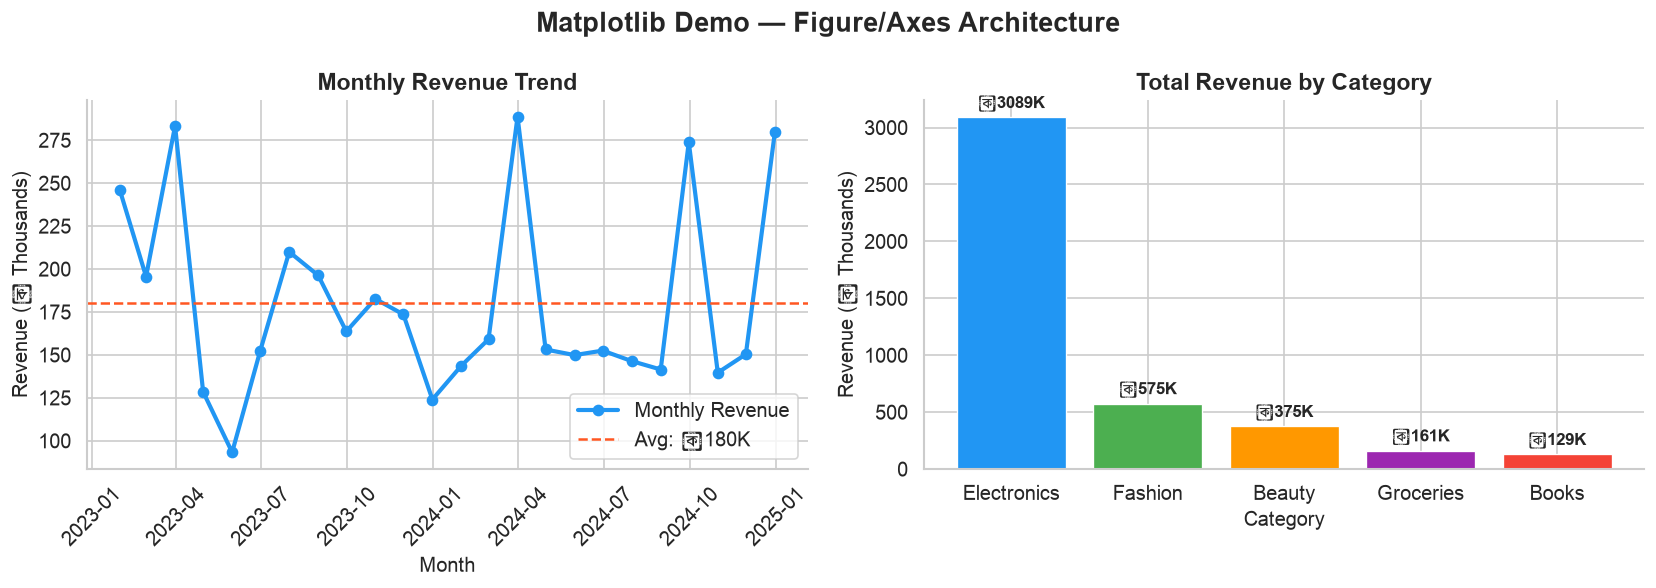

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 2.1 — The Figure / Axes Relationship
# ─────────────────────────────────────────────────────────────

# WHY explicit fig, ax style:
# When you have multiple subplots, plt.* functions act on the
# "currently active" axes — which can be wrong if you're not careful.
# Explicit ax objects remove all ambiguity. Always use this in production.

# ── Create a 1×2 subplot layout ─────────────────────────────
# sharey=True: both subplots share the same y-axis scale → easier comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Matplotlib Demo — Figure/Axes Architecture', fontsize=16, fontweight='bold')

# ── LEFT SUBPLOT: Monthly Revenue Trend (Line Plot) ─────────
# WHAT: Groups revenue by month and plots the total over time.
# MOTIVE: Show how business performance evolves — the most
# fundamental business question: "Are we growing?"

# Resample by month-end, sum revenue
# WHY 'ME': Month-End frequency — aligns data to last day of each month
monthly = df.set_index('order_date')['revenue'].resample('ME').sum() / 1_000  # Convert to thousands

ax1.plot(
    monthly.index,
    monthly.values,
    color='#2196F3',      # WHY: Blue = trust/performance in business contexts
    linewidth=2.5,
    marker='o',           # WHY: Circle markers show exact data points
    markersize=6,
    label='Monthly Revenue'
)

# Add a horizontal mean line for reference
# WHY: Shows how each month compares to the average — immediately useful insight
ax1.axhline(
    monthly.mean(),
    color='#FF5722',
    linestyle='--',
    linewidth=1.5,
    label=f'Avg: ৳{monthly.mean():.0f}K'
)

ax1.set_title('Monthly Revenue Trend')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (৳ Thousands)')
ax1.legend()
# WHY rotate: Month labels overlap if horizontal — rotating 45° prevents clutter
ax1.tick_params(axis='x', rotation=45)

# ── RIGHT SUBPLOT: Revenue by Category (Bar Chart) ──────────
# WHAT: Shows total revenue contribution of each product category.
# MOTIVE: Identify which categories drive the most revenue.

cat_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False) / 1_000

bars = ax2.bar(
    cat_revenue.index,
    cat_revenue.values,
    color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'],
    edgecolor='white',
    linewidth=0.8,
)

# Add value labels on top of each bar
# WHY: Readers shouldn't have to squint at the axis. Labels = instant readability.
for bar, val in zip(bars, cat_revenue.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,  # Center horizontally
        bar.get_height() + 50,               # Slightly above bar top
        f'৳{val:.0f}K',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax2.set_title('Total Revenue by Category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Revenue (৳ Thousands)')

plt.tight_layout()  # WHY: Prevents subplots from overlapping each other
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2.2 — Subplots with Different Chart Types
# ─────────────────────────────────────────────────────────────
# WHY: Practice combining different chart types in one figure.
# This is how dashboards are built — multiple views of the same data.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Matplotlib — Multi-Panel Chart Types', fontsize=16, fontweight='bold')

# ── TOP LEFT: Scatter Plot (Quantity vs Revenue) ─────────────
# WHAT: Shows relationship between quantity ordered and revenue earned.
# MOTIVE: Do bulk orders always mean higher revenue? (Not always — depends on price)
ax = axes[0, 0]  # Row 0, Column 0
ax.scatter(
    df['quantity'], df['revenue'],
    alpha=0.3,            # WHY: Low alpha handles overplotting — thousands of points
    color='steelblue',
    s=20                  # WHY: Small size prevents blobs in dense regions
)
ax.set_title('Quantity vs Revenue')
ax.set_xlabel('Quantity')
ax.set_ylabel('Revenue (৳)')

# ── TOP RIGHT: Histogram (Revenue Distribution) ───────────────
# WHAT: Shows the shape of revenue values across all orders.
# MOTIVE: Is revenue normally distributed or heavily skewed?
# This matters for which statistics we should use.
ax = axes[0, 1]
ax.hist(
    df['revenue'].clip(upper=df['revenue'].quantile(0.99)),  # WHY clip: Outliers compress the histogram
    bins=40,
    color='#4CAF50',
    edgecolor='white',
    linewidth=0.5,
)
ax.set_title('Revenue Distribution (99th pct clipped)')
ax.set_xlabel('Revenue (৳)')
ax.set_ylabel('Order Count')

# ── BOTTOM LEFT: Horizontal Bar (Orders by Region) ───────────
# WHY horizontal: Region names are long — horizontal bars give them room.
ax = axes[1, 0]
region_counts = df['customer_region'].value_counts()
ax.barh(
    region_counts.index,
    region_counts.values,
    color='#FF9800',
    edgecolor='white',
)
ax.set_title('Orders by Region')
ax.set_xlabel('Order Count')

# ── BOTTOM RIGHT: Pie Chart (Payment Method Share) ───────────
# WHY pie here: Payment method is a proportional composition (shares add to 100%).
# Pie charts work for <= 5 categories showing composition.
ax = axes[1, 1]
pay_counts = df['payment_method'].value_counts()
ax.pie(
    pay_counts.values,
    labels=pay_counts.index,
    autopct='%1.1f%%',    # WHY: Show percentage on each slice
    startangle=90,        # WHY: Start at 12 o'clock — conventional for pie charts
    colors=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
)
ax.set_title('Payment Method Distribution')

plt.tight_layout()
plt.show()

---
## Section 3 — Seaborn Smart Visualization

### Why Seaborn after Matplotlib?
Now that you understand the Figure/Axes foundation, Seaborn becomes a *productivity multiplier*.
You can use Seaborn for the heavy lifting and drop back to Matplotlib for fine-tuning.

**Key pattern:** `sns.some_plot(data=df, x='col_a', y='col_b', hue='col_c', ax=ax_object)`

**Analogy:** You know how to build furniture by hand (Matplotlib). Seaborn is the CNC router —
it does 90% of the cutting automatically. You still do the assembly and finishing.

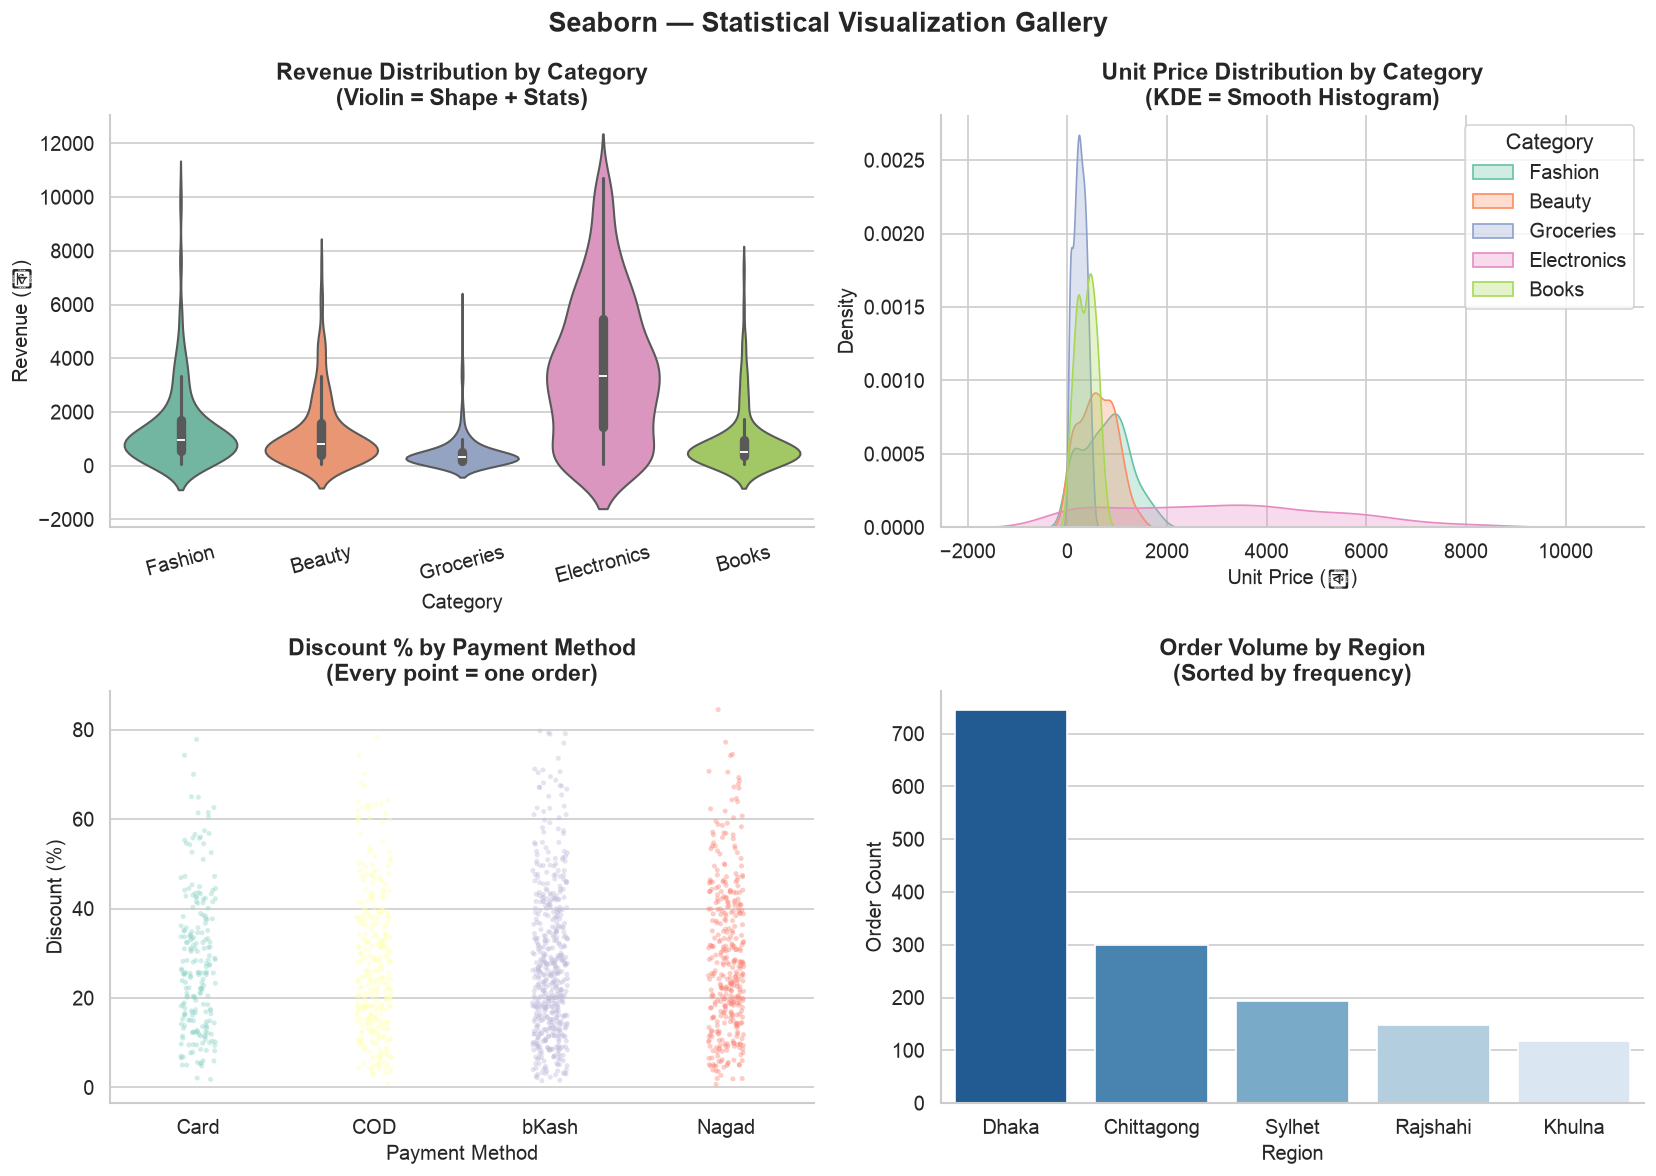

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 3.1 — Seaborn Statistical Plots
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seaborn — Statistical Visualization Gallery', fontsize=16, fontweight='bold')

# ── TOP LEFT: Violin Plot (Revenue by Category) ──────────────
# WHAT: Violin = boxplot + mirrored KDE. Shows distribution SHAPE,
# not just summary statistics.
# MOTIVE: See if Electronics revenue has one peak or two (bimodal).
# A boxplot would miss bimodality — a violin catches it.
ax = axes[0, 0]
# Clip extreme outliers for visualization — outliers compress violin shape
df_viz = df[df['revenue'] < df['revenue'].quantile(0.95)].copy()
sns.violinplot(
    data=df_viz, x='category', y='revenue',
    palette='Set2',
    inner='box',     # WHY inner='box': Show the boxplot inside the violin
    ax=ax
)
ax.set_title('Revenue Distribution by Category\n(Violin = Shape + Stats)')
ax.set_xlabel('Category')
ax.set_ylabel('Revenue (৳)')
ax.tick_params(axis='x', rotation=15)

# ── TOP RIGHT: KDE Plot (Unit Price by Category) ─────────────
# WHAT: Smooth probability density curve for each category.
# MOTIVE: Compare pricing profile of each category on same axes.
# Do Electronics and Groceries have overlapping price ranges?
ax = axes[0, 1]
for cat in df['category'].unique():
    data_cat = df[df['category'] == cat]['unit_price']
    data_cat = data_cat[data_cat < data_cat.quantile(0.99)]  # Remove extreme outliers
    sns.kdeplot(data=data_cat, ax=ax, label=cat, fill=True, alpha=0.3)

ax.set_title('Unit Price Distribution by Category\n(KDE = Smooth Histogram)')
ax.set_xlabel('Unit Price (৳)')
ax.set_ylabel('Density')
ax.legend(title='Category')

# ── BOTTOM LEFT: Stripplot (Discount by Payment Method) ──────
# WHAT: Every individual data point plotted, jittered to avoid overlap.
# MOTIVE: See the full data, not just summaries. Are bKash orders
# consistently given higher discounts?
ax = axes[1, 0]
sns.stripplot(
    data=df.dropna(subset=['discount_pct']),
    x='payment_method', y='discount_pct',
    palette='Set3',
    alpha=0.4,
    jitter=True,   # WHY: Spreads overlapping points so you can see density
    size=3,
    ax=ax
)
ax.set_title('Discount % by Payment Method\n(Every point = one order)')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Discount (%)')

# ── BOTTOM RIGHT: Countplot (Orders by Region) ───────────────
# WHAT: Bar chart of categorical counts — automatically counts rows.
# MOTIVE: Geographic distribution of demand. Where do most orders come from?
ax = axes[1, 1]
sns.countplot(
    data=df, x='customer_region',
    order=df['customer_region'].value_counts().index,  # WHY order: Sort by count descending
    palette='Blues_r',
    ax=ax
)
ax.set_title('Order Volume by Region\n(Sorted by frequency)')
ax.set_xlabel('Region')
ax.set_ylabel('Order Count')

plt.tight_layout()
plt.show()

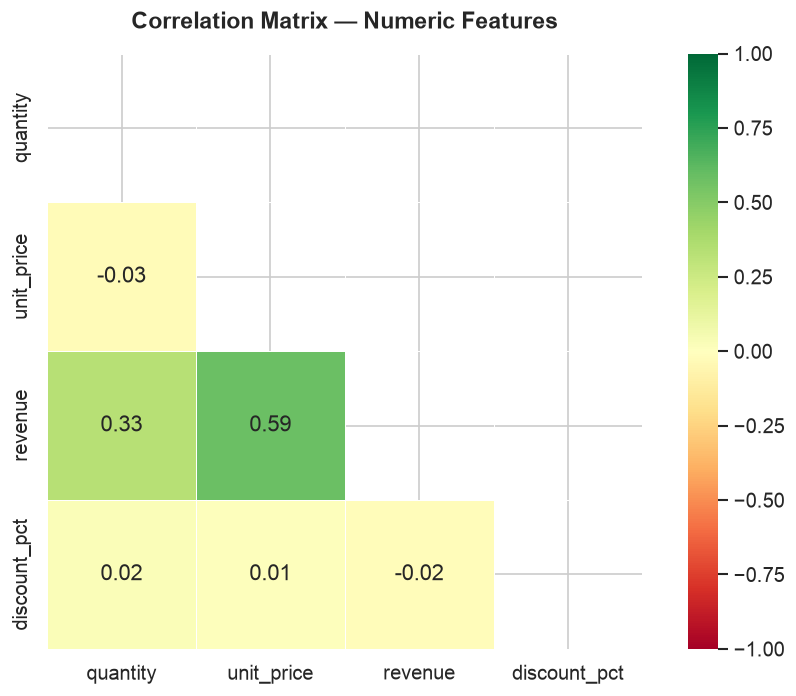


📊 CORRELATION INTERPRETATION:
  |r| > 0.7  → Strong correlation
  |r| 0.4–0.7 → Moderate correlation
  |r| < 0.4  → Weak/No correlation

Top correlated pairs:
unit_price  revenue         0.585043
quantity    revenue         0.334217
            discount_pct    0.024242
unit_price  discount_pct    0.011827
revenue     discount_pct   -0.021044
quantity    unit_price     -0.028872


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 3.2 — Correlation Heatmap (Seaborn's Most Powerful EDA Tool)
# ─────────────────────────────────────────────────────────────
# WHAT: Pearson correlation coefficient between every pair of
# numeric columns, displayed as a color-coded matrix.
# MOTIVE: Quickly identify which features are related.
#   - Values near +1: Strong positive relationship
#   - Values near -1: Strong negative relationship
#   - Values near 0:  No linear relationship
# This is critical for:
#   1. Feature selection (remove one of two highly correlated features)
#   2. Understanding business drivers (does price affect quantity?)

numeric_cols = ['quantity', 'unit_price', 'revenue', 'discount_pct']
corr_matrix = df[numeric_cols].corr()  # WHY .corr(): Pandas computes Pearson by default

fig, ax = plt.subplots(figsize=(8, 6))

# Generate a mask for the upper triangle — we only need half the matrix
# (it's symmetric: correlation of A with B = correlation of B with A)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,         # WHY: Print the actual correlation value in each cell
    fmt='.2f',          # WHY: Show 2 decimal places (e.g., 0.87)
    cmap='RdYlGn',      # WHY: Red=negative, Yellow=zero, Green=positive — intuitive
    mask=mask,          # WHY: Show only lower triangle — avoids redundancy
    vmin=-1, vmax=1,    # WHY: Fix scale — correlation is always between -1 and 1
    linewidths=0.5,
    square=True,        # WHY: Square cells look cleaner than rectangles
    ax=ax
)

ax.set_title('Correlation Matrix — Numeric Features', pad=15)
plt.tight_layout()
plt.show()

# ── Interpretation Guide ────────────────────────────────────
print("\n📊 CORRELATION INTERPRETATION:")
print("  |r| > 0.7  → Strong correlation")
print("  |r| 0.4–0.7 → Moderate correlation")
print("  |r| < 0.4  → Weak/No correlation")
print("\nTop correlated pairs:")

# Find top correlations (excluding self-correlation which is always 1.0)
corr_pairs = (
    corr_matrix.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)
# Filter out self-correlations (exactly 1.0)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.head(6).to_string())

---
## Section 4 — Mean, Median, Mode

### Why this section?
These are the simplest statistics — but also the most misused.
Choosing the wrong central measure leads to bad business decisions.

**Analogy:**
- **Mean** = Balance point of a seesaw. One heavy person on one end tilts everything.
- **Median** = The person standing in the exact middle of a queue. Doesn't care about outliers.
- **Mode** = The most popular dish on a restaurant menu. What most people ordered.

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 4.1 — Mean vs. Median: The Outlier Effect
# ─────────────────────────────────────────────────────────────
# WHAT: Demonstrates how outliers drag the mean but not the median.
# MOTIVE: Build the intuition for WHEN to use each measure.

# ── Normal Data ─────────────────────────────────────────────
normal_orders = [500, 800, 1200, 900, 650, 1100, 750, 950, 600, 870]

# ── Same Data + Outlier (one bulk enterprise order) ─────────
outlier_orders = normal_orders + [85000]  # One massive enterprise order

# ── Compute Statistics ───────────────────────────────────────
print("═" * 50)
print("DATASET A: Normal customer orders")
print(f"  Data:   {normal_orders}")
print(f"  Mean:   ৳{np.mean(normal_orders):,.0f}")
print(f"  Median: ৳{np.median(normal_orders):,.0f}")
print(f"  Mode:   Not applicable (all unique)")

print("\n" + "═" * 50)
print("DATASET B: Same + one enterprise order of ৳85,000")
print(f"  Data:   {outlier_orders}")
print(f"  Mean:   ৳{np.mean(outlier_orders):,.0f}")
print(f"  Median: ৳{np.median(outlier_orders):,.0f}")
print()

print("INSIGHT: One outlier increased the mean by", end=' ')
change = np.mean(outlier_orders) - np.mean(normal_orders)
print(f"৳{change:,.0f} ({change/np.mean(normal_orders)*100:.0f}%)")
print("         but only changed the median by", end=' ')
m_change = np.median(outlier_orders) - np.median(normal_orders)
print(f"৳{m_change:,.0f}")
print("=> Report median as the 'typical' order value for this dataset.")

══════════════════════════════════════════════════
DATASET A: Normal customer orders
  Data:   [500, 800, 1200, 900, 650, 1100, 750, 950, 600, 870]
  Mean:   ৳832
  Median: ৳835
  Mode:   Not applicable (all unique)

══════════════════════════════════════════════════
DATASET B: Same + one enterprise order of ৳85,000
  Data:   [500, 800, 1200, 900, 650, 1100, 750, 950, 600, 870, 85000]
  Mean:   ৳8,484
  Median: ৳870

INSIGHT: One outlier increased the mean by ৳7,652 (920%)
         but only changed the median by ৳35
=> Report median as the 'typical' order value for this dataset.


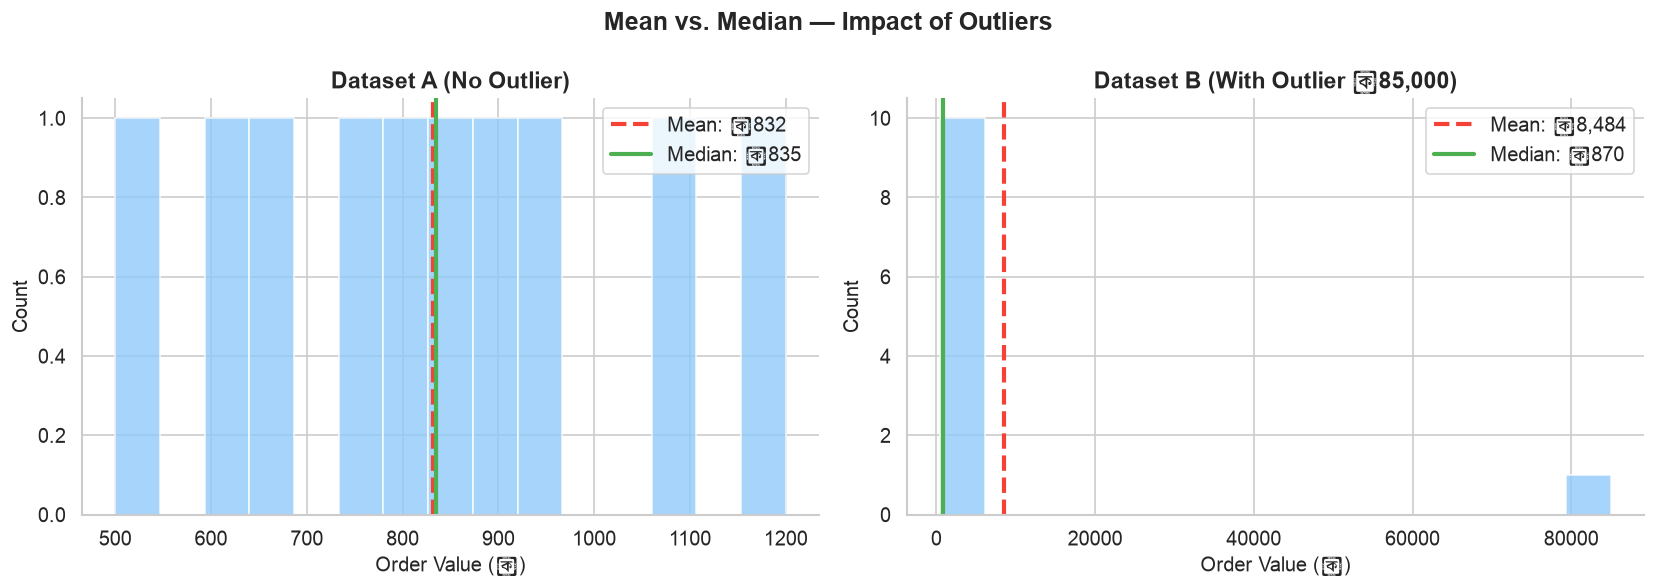

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 4.2 — Mean vs. Median Visualization
# ─────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mean vs. Median — Impact of Outliers', fontsize=15, fontweight='bold')

for ax, data, title in zip(
    [ax1, ax2],
    [normal_orders, outlier_orders],
    ['Dataset A (No Outlier)', 'Dataset B (With Outlier ৳85,000)']
):
    ax.hist(data, bins=15, color='#90CAF9', edgecolor='white', alpha=0.8)
    
    # WHY axvline: Vertical lines clearly mark where mean and median fall
    ax.axvline(np.mean(data),   color='#F44336', linewidth=2.5,
            linestyle='--',  label=f'Mean: ৳{np.mean(data):,.0f}')
    ax.axvline(np.median(data), color='#4CAF50', linewidth=2.5,
            linestyle='-',   label=f'Median: ৳{np.median(data):,.0f}')
    
    ax.set_title(title)
    ax.set_xlabel('Order Value (৳)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 4.3 — Mode for Categorical Data
# ─────────────────────────────────────────────────────────────
# WHY: Mode is the ONLY valid central tendency for categorical data.
# You can't average product names or payment methods.

print("═" * 50)
print("MODE ANALYSIS — Categorical Features")
print("═" * 50)

categorical_cols = ['category', 'customer_region', 'payment_method']

for col in categorical_cols:
    mode_val = df[col].mode()[0]      # [0] because mode() returns a Series
    mode_count = (df[col] == mode_val).sum()
    mode_pct = mode_count / len(df) * 100
    print(f"\n{col.upper()}")
    print(f"  Mode:  {mode_val}")
    print(f"  Count: {mode_count:,} orders ({mode_pct:.1f}% of all orders)")
    print(f"  Value counts:")
    vc = df[col].value_counts()
    for val, cnt in vc.items():
        bar = '█' * int(cnt / len(df) * 50)
        print(f"    {val:15s} {bar} {cnt:,}")

print()
print("BUSINESS INSIGHT:")
print(f"  Most popular category: {df['category'].mode()[0]}")
print(f"  Most popular payment:  {df['payment_method'].mode()[0]}")
print(f"  Top region:            {df['customer_region'].mode()[0]}")

══════════════════════════════════════════════════
MODE ANALYSIS — Categorical Features
══════════════════════════════════════════════════

CATEGORY
  Mode:  Electronics
  Count: 466 orders (31.1% of all orders)
  Value counts:
    Electronics     ███████████████ 466
    Fashion         ███████████ 349
    Groceries       ██████████ 305
    Beauty          ████████ 243
    Books           ████ 137

CUSTOMER_REGION
  Mode:  Dhaka
  Count: 744 orders (49.6% of all orders)
  Value counts:
    Dhaka           ████████████████████████ 744
    Chittagong      █████████ 299
    Sylhet          ██████ 193
    Rajshahi        ████ 147
    Khulna          ███ 117

PAYMENT_METHOD
  Mode:  bKash
  Count: 534 orders (35.6% of all orders)
  Value counts:
    bKash           █████████████████ 534
    Nagad           ████████████ 389
    COD             ███████████ 345
    Card            ███████ 232

BUSINESS INSIGHT:
  Most popular category: Electronics
  Most popular payment:  bKash
  Top region:  

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 4.4 — Full Descriptive Stats Summary Table
# ─────────────────────────────────────────────────────────────
# WHAT: A clean, extended version of df.describe() with added
# statistics: median, mode, skewness, kurtosis.
# MOTIVE: df.describe() misses median, mode, and distribution shape.
# This gives a complete picture in one table.

def extended_describe(df, numeric_cols):
    """Compute extended descriptive statistics beyond df.describe()."""
    results = []
    for col in numeric_cols:
        s = df[col].dropna()
        results.append({
            'Column':    col,
            'Count':     len(s),
            'Mean':      s.mean(),
            'Median':    s.median(),
            'Mode':      s.mode()[0],
            'Std Dev':   s.std(),
            'Variance':  s.var(),
            'Min':       s.min(),
            'Max':       s.max(),
            'Skewness':  s.skew(),
            'Kurtosis':  s.kurtosis(),
            'Missing %': df[col].isna().mean() * 100
        })
    return pd.DataFrame(results).set_index('Column').round(2)

numeric_cols = ['quantity', 'unit_price', 'revenue', 'discount_pct']
stats_table = extended_describe(df, numeric_cols)

print("\n══ EXTENDED DESCRIPTIVE STATISTICS ══\n")
display(stats_table.T)  # Transpose for easier reading

print("\n📝 HOW TO READ SKEWNESS:")
print("  Skewness ≈ 0     → Symmetric (normal-like)")
print("  Skewness > 1     → Strongly right-skewed (long tail on right)")
print("  Skewness < -1    → Strongly left-skewed (long tail on left)")


══ EXTENDED DESCRIPTIVE STATISTICS ══



Column,quantity,unit_price,revenue,discount_pct
Count,1500.00,1500.00,1500.00,1425.00
Mean,1.97,1367.53,2885.36,28.04
Median,1.00,596.54,917.33,25.50
Mode,1.00,50.00,50.00,20.50
Std Dev,1.98,1834.60,6402.36,16.34
Variance,3.91,3365740.96,40990233.74,267.06
Min,1.00,50.00,50.00,0.70
Max,19.00,11107.73,96190.86,84.50
Skewness,3.73,2.11,6.45,0.69
Kurtosis,18.82,4.38,58.73,0.04



📝 HOW TO READ SKEWNESS:
  Skewness ≈ 0     → Symmetric (normal-like)
  Skewness > 1     → Strongly right-skewed (long tail on right)
  Skewness < -1    → Strongly left-skewed (long tail on left)


---
## Section 5 — Standard Deviation & Variance

### Why this section?
Central tendency tells you the *location* of data. Spread tells you the *width*.
Without spread, the mean is meaningless — knowing average salary is ৳50,000/month
tells you nothing if the range is ৳20,000 to ৳2,000,000.

**Analogy:** If mean is GPS coordinates, standard deviation is the radius of uncertainty.
"You are at 23.8°N, 90.4°E ± 10 meters" vs. "± 5 km" — same coordinates, very different reliability.

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 5.1 — Variance and Std Dev from Scratch
# ─────────────────────────────────────────────────────────────
# WHY build from scratch: Understanding the formula prevents
# blindly trusting library outputs. You need to know WHY
# we subtract the mean and square the differences.

data = [2, 4, 4, 4, 5, 5, 7, 9]
print("Data:", data)
print(f"N = {len(data)} (using sample variance, so denominator = N-1 = {len(data)-1})")
print()

# Step 1: Mean
mean = sum(data) / len(data)
print(f"Step 1 — Mean: {mean}")

# Step 2: Deviations from mean
deviations = [x - mean for x in data]
print(f"Step 2 — Deviations: {[round(d, 1) for d in deviations]}")
print(f"         Sum of deviations: {sum(deviations):.10f} (should be ≈ 0)")

# Step 3: Squared deviations (eliminates negatives, penalizes large errors more)
sq_dev = [d**2 for d in deviations]
print(f"Step 3 — Squared deviations: {[round(s, 1) for s in sq_dev]}")

# Step 4: Sample variance (divide by N-1, not N)
variance = sum(sq_dev) / (len(data) - 1)  # ddof=1 for sample
print(f"Step 4 — Sample Variance: {sum(sq_dev)} / {len(data)-1} = {variance:.4f}")

# Step 5: Standard deviation = sqrt(variance)
std_dev = variance ** 0.5
print(f"Step 5 — Std Dev: √{variance:.4f} = {std_dev:.4f}")

print()
print("══ VERIFICATION WITH NumPy ══")
print(f"np.var(data, ddof=1): {np.var(data, ddof=1):.4f}")
print(f"np.std(data, ddof=1): {np.std(data, ddof=1):.4f}")
print("✅ Manual calculation matches NumPy" if abs(std_dev - np.std(data, ddof=1)) < 0.0001 else "❌ Mismatch — check formula")

Data: [2, 4, 4, 4, 5, 5, 7, 9]
N = 8 (using sample variance, so denominator = N-1 = 7)

Step 1 — Mean: 5.0
Step 2 — Deviations: [-3.0, -1.0, -1.0, -1.0, 0.0, 0.0, 2.0, 4.0]
         Sum of deviations: 0.0000000000 (should be ≈ 0)
Step 3 — Squared deviations: [9.0, 1.0, 1.0, 1.0, 0.0, 0.0, 4.0, 16.0]
Step 4 — Sample Variance: 32.0 / 7 = 4.5714
Step 5 — Std Dev: √4.5714 = 2.1381

══ VERIFICATION WITH NumPy ══
np.var(data, ddof=1): 4.5714
np.std(data, ddof=1): 2.1381
✅ Manual calculation matches NumPy


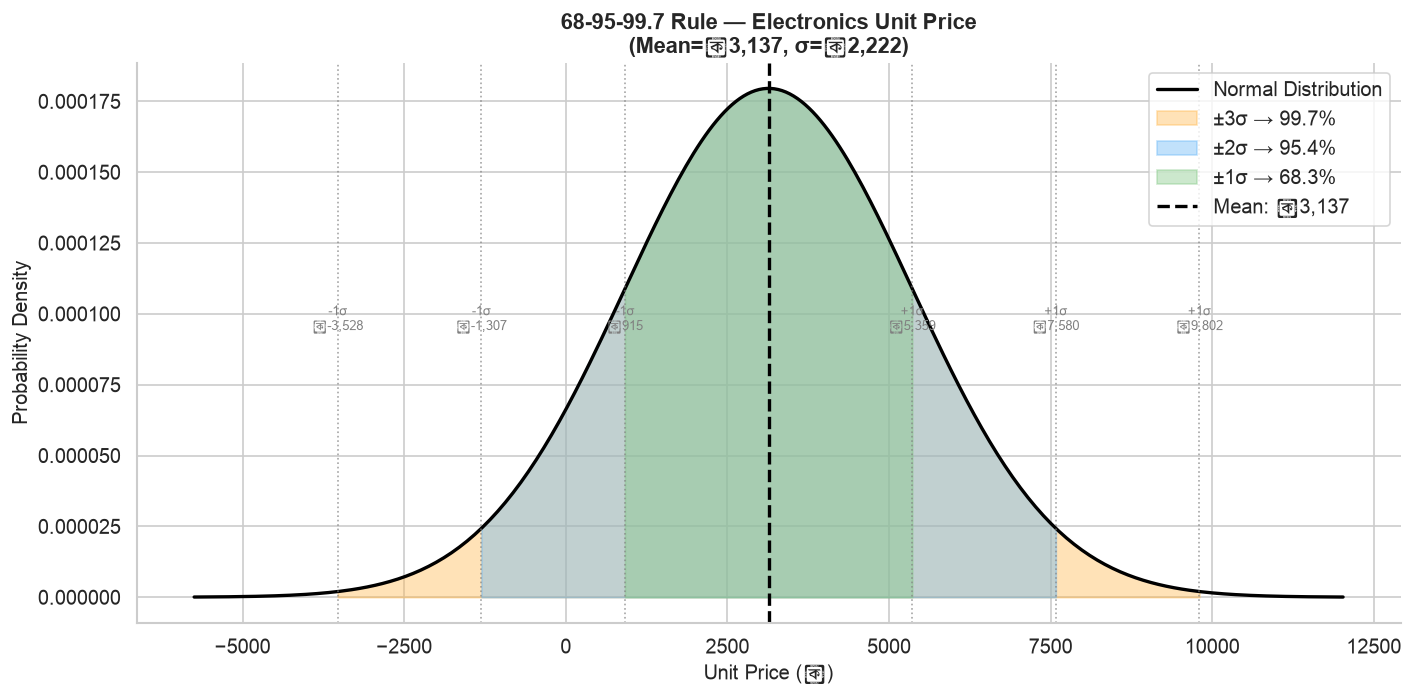


3-Sigma Bounds: ৳-3,528 to ৳9,802
Outliers detected: 0 (0.0%)


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 5.2 — The 68-95-99.7 Rule Visualized
# ─────────────────────────────────────────────────────────────
# WHAT: Visualize how standard deviation carves up a normal distribution.
# MOTIVE: This rule is the foundation of outlier detection (|z| > 3)
# and statistical significance testing.

fig, ax = plt.subplots(figsize=(12, 6))

# Generate a normal distribution for unit_price (approximately normal per category)
# Use electronics prices as a near-normal example
electronics_prices = df[df['category']=='Electronics']['unit_price']
electronics_prices = electronics_prices[electronics_prices < electronics_prices.quantile(0.99)]

mu = electronics_prices.mean()
sigma = electronics_prices.std()

# Generate x range for plotting
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
y = stats.norm.pdf(x, mu, sigma)  # Normal distribution PDF

# Draw the main curve
ax.plot(x, y, 'k-', linewidth=2, label='Normal Distribution')

# Color the standard deviation bands
# WHY fill_between: Visually fills the area under the curve between bounds
bands = [
    (1, '#81C784', '±1σ → 68.3%'),   # Light green
    (2, '#64B5F6', '±2σ → 95.4%'),   # Light blue
    (3, '#FFB74D', '±3σ → 99.7%'),   # Light orange
]

for n_sigma, color, label in reversed(bands):  # Reversed so smaller bands appear on top
    x_band = np.linspace(mu - n_sigma*sigma, mu + n_sigma*sigma, 300)
    y_band = stats.norm.pdf(x_band, mu, sigma)
    ax.fill_between(x_band, y_band, alpha=0.4, color=color, label=label)

# Add vertical lines at each sigma
for n_sigma, color, _ in bands:
    for sign in [-1, 1]:
        ax.axvline(mu + sign*n_sigma*sigma, color='gray',
                linestyle=':', linewidth=1, alpha=0.7)
        ax.text(mu + sign*n_sigma*sigma, ax.get_ylim()[1]*0.5 if ax.get_ylim()[1] > 0 else 0.0003,
                f'{sign:+d}σ\n৳{mu + sign*n_sigma*sigma:,.0f}',
                ha='center', fontsize=8, color='gray')

ax.axvline(mu, color='black', linewidth=2, linestyle='--', label=f'Mean: ৳{mu:,.0f}')

ax.set_title(f'68-95-99.7 Rule — Electronics Unit Price\n(Mean=৳{mu:,.0f}, σ=৳{sigma:,.0f})',
            fontsize=13)
ax.set_xlabel('Unit Price (৳)')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Outlier detection using 3-sigma rule
lower_bound = mu - 3*sigma
upper_bound = mu + 3*sigma
outliers = electronics_prices[(electronics_prices < lower_bound) | (electronics_prices > upper_bound)]
print(f"\n3-Sigma Bounds: ৳{lower_bound:,.0f} to ৳{upper_bound:,.0f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(electronics_prices)*100:.1f}%)")

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 5.3 — Comparing Spread: Coefficient of Variation
# ─────────────────────────────────────────────────────────────
# WHY CV: Standard deviation alone can't compare spread between
# variables with different scales.
# Example: Electronics std=৳2500, Groceries std=৳150.
# Which is more volatile? Without normalizing by the mean, we can't tell.
# CV = (std/mean) × 100% → A relative, scale-independent measure.

print("═" * 55)
print("COEFFICIENT OF VARIATION — Revenue Volatility by Category")
print("CV = (Std Dev / Mean) × 100%")
print("═" * 55)

cv_results = []
for cat in df['category'].unique():
    cat_data = df[df['category'] == cat]['revenue']
    mean_val = cat_data.mean()
    std_val  = cat_data.std()
    cv       = (std_val / mean_val) * 100
    cv_results.append({'Category': cat, 'Mean (৳)': mean_val, 'Std Dev (৳)': std_val, 'CV (%)': cv})

cv_df = pd.DataFrame(cv_results).sort_values('CV (%)', ascending=False)
cv_df[['Mean (৳)', 'Std Dev (৳)']] = cv_df[['Mean (৳)', 'Std Dev (৳)']].round(0)
cv_df['CV (%)'] = cv_df['CV (%)'].round(1)
print(cv_df.to_string(index=False))
print()
print(f"Most volatile category:  {cv_df.iloc[0]['Category']} (CV={cv_df.iloc[0]['CV (%)']:.1f}%)")
print(f"Most stable category:    {cv_df.iloc[-1]['Category']} (CV={cv_df.iloc[-1]['CV (%)']:.1f}%)")
print("\nHigh CV → unpredictable revenue (harder to forecast)")
print("Low CV  → stable revenue (easier to plan inventory and staffing)")

═══════════════════════════════════════════════════════
COEFFICIENT OF VARIATION — Revenue Volatility by Category
CV = (Std Dev / Mean) × 100%
═══════════════════════════════════════════════════════
   Category  Mean (৳)  Std Dev (৳)  CV (%)
     Beauty    1542.0       4478.0   290.5
    Fashion    1648.0       3222.0   195.5
Electronics    6628.0       9605.0   144.9
  Groceries     526.0        749.0   142.2
      Books     941.0       1189.0   126.3

Most volatile category:  Beauty (CV=290.5%)
Most stable category:    Books (CV=126.3%)

High CV → unpredictable revenue (harder to forecast)
Low CV  → stable revenue (easier to plan inventory and staffing)


---
## Section 6 — Distribution Analysis: Histograms & Boxplots

### Why this section?
Mean and std dev describe a distribution in 2 numbers. But distributions have *shapes* that
numbers alone don't capture. A histogram is a photograph of your data's shape.

**Analogy:**
- **Histogram** = A cross-section of a river. Shows how water depth is distributed across the width.
- **Boxplot** = A river gauge station. Gives you 5 key readings (Q1, median, Q3, whiskers) without showing the full shape.

Use histograms to discover shape. Use boxplots to compare groups.

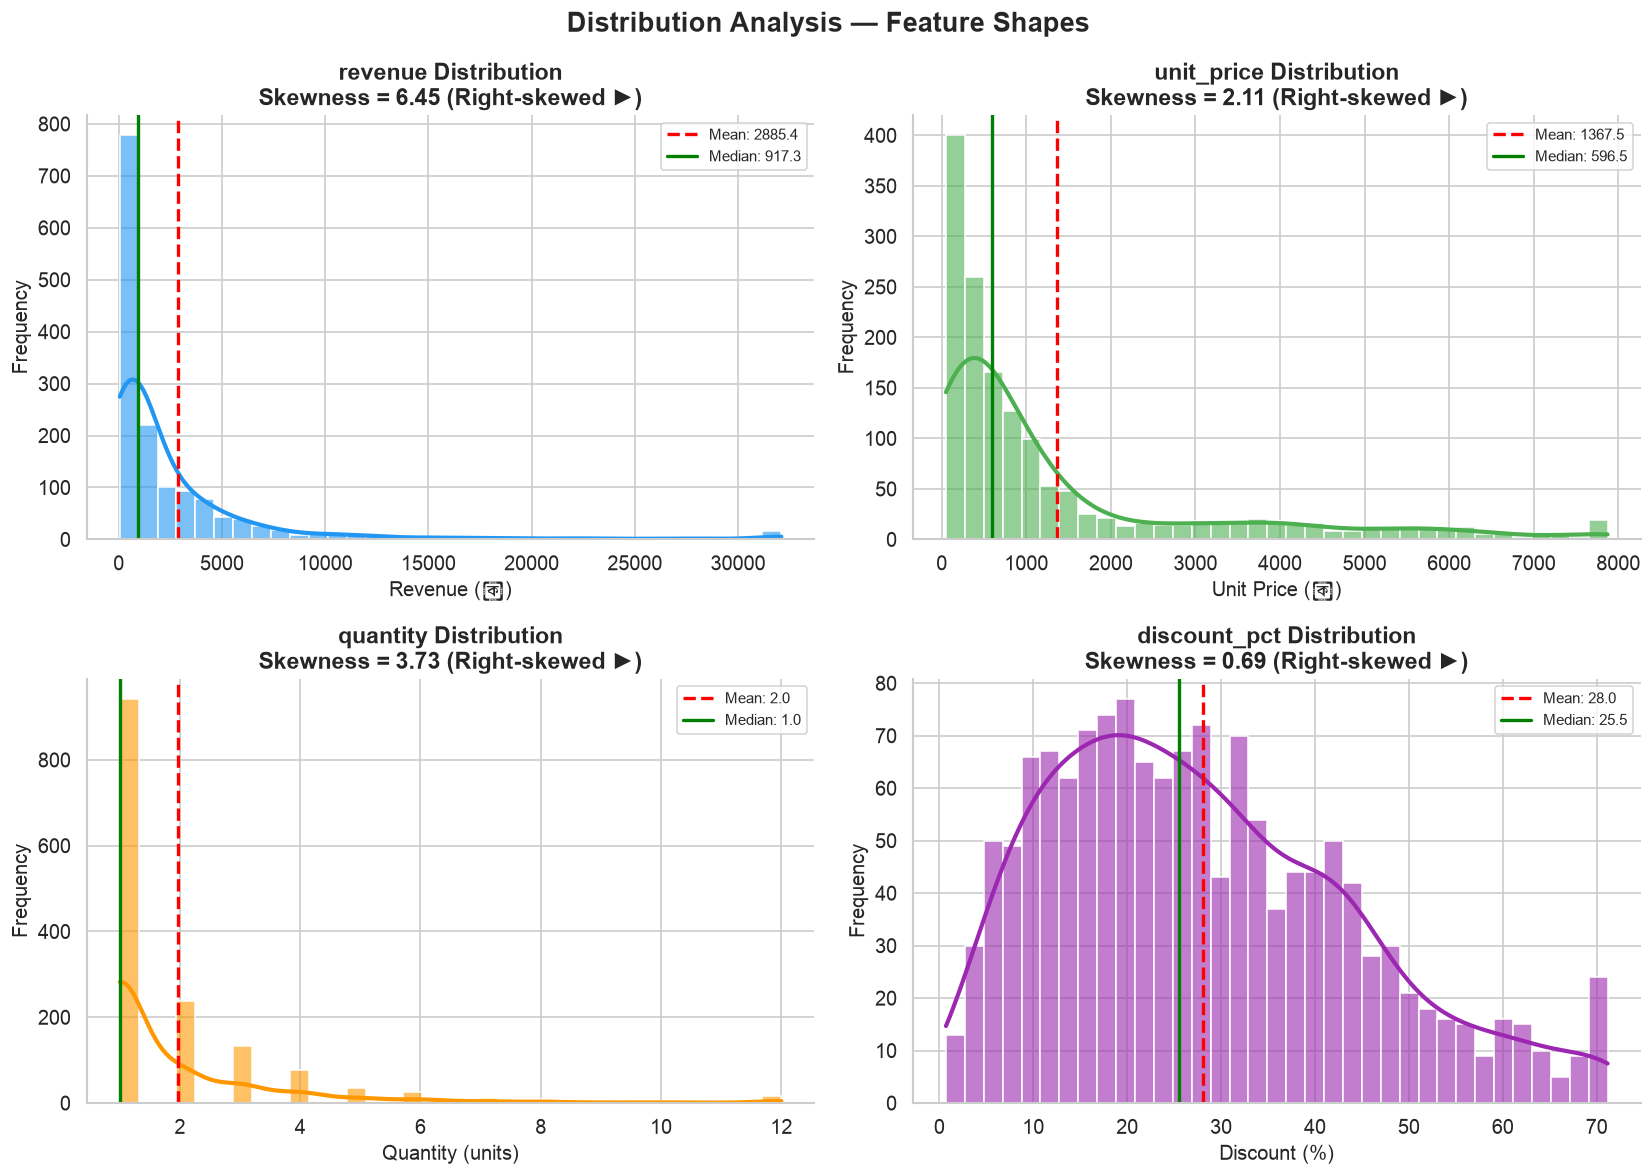


📊 SKEWNESS INTERPRETATION:
  revenue        : skewness=+6.45  → Consider log transform
  unit_price     : skewness=+2.11  → Consider log transform
  quantity       : skewness=+3.73  → Consider log transform
  discount_pct   : skewness=+0.69  


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 6.1 — Histogram: Distribution Shapes
# ─────────────────────────────────────────────────────────────
# WHAT: Compare the distribution shape of different numeric features.
# MOTIVE: Identify which features are normally distributed, which are skewed,
# and which need transformation before ML modeling.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution Analysis — Feature Shapes', fontsize=16, fontweight='bold')

plot_configs = [
    ('revenue',      'Revenue (৳)',       '#2196F3', 0, 0),
    ('unit_price',   'Unit Price (৳)',    '#4CAF50', 0, 1),
    ('quantity',     'Quantity (units)',  '#FF9800', 1, 0),
    ('discount_pct', 'Discount (%)',      '#9C27B0', 1, 1),
]

for col, xlabel, color, row, col_idx in plot_configs:
    ax = axes[row, col_idx]
    data = df[col].dropna()
    
    # Clip at 99th percentile for visualization (outliers compress the histogram)
    # WHY: With extreme outliers, most bars get squished to the left,
    # making the shape unreadable. Clipping for visualization only — we don't modify the data.
    data_clipped = data.clip(upper=data.quantile(0.99))
    
    # Histogram with KDE overlay
    sns.histplot(data=data_clipped, bins=35, kde=True,
                 color=color, alpha=0.6, ax=ax,
                 line_kws={'linewidth': 2.5})
    
    # Add mean and median lines
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=2,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='-',  linewidth=2,
               label=f'Median: {data.median():.1f}')
    
    # Compute and display skewness
    skew_val = data.skew()
    skew_label = 'Right-skewed ►' if skew_val > 0.5 else ('◄ Left-skewed' if skew_val < -0.5 else 'Approx. Symmetric')
    
    ax.set_title(f'{col} Distribution\nSkewness = {skew_val:.2f} ({skew_label})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 SKEWNESS INTERPRETATION:")
for col, xlabel, _, _, _ in plot_configs:
    skew = df[col].dropna().skew()
    action = '→ Consider log transform' if skew > 1 else ('→ Approximately normal' if abs(skew) < 0.5 else '')
    print(f"  {col:15s}: skewness={skew:+.2f}  {action}")

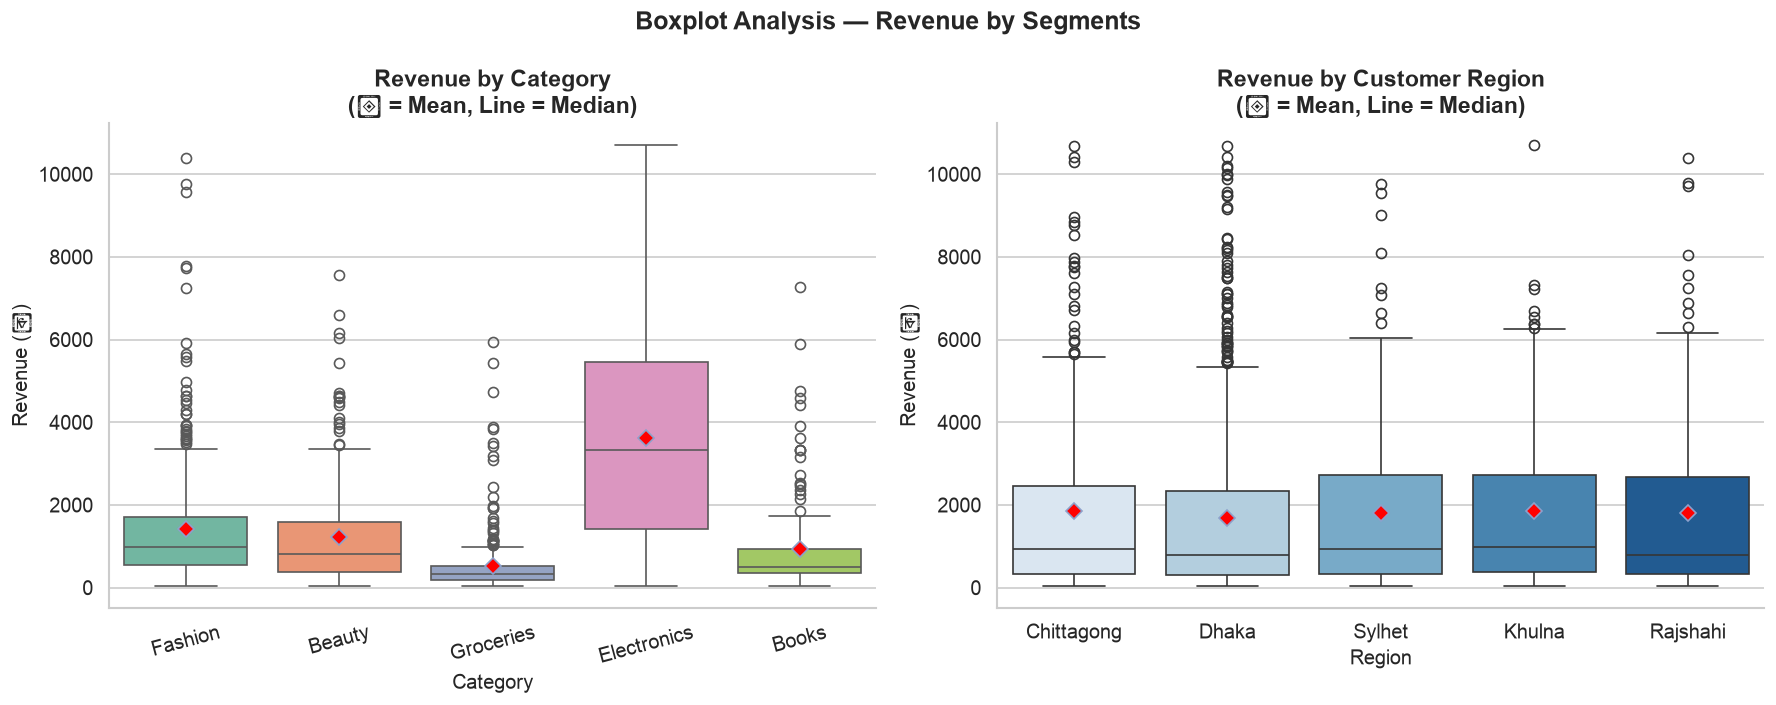


══ FIVE-NUMBER SUMMARY BY CATEGORY ══

Fashion
  Q1=     543 | Median=     975 | Q3=   1,770 | IQR=   1,227
  Whisker range: ৳-1,298 – ৳3,610
  Outliers: 31 orders (8.9%)

Beauty
  Q1=     386 | Median=     815 | Q3=   1,599 | IQR=   1,214
  Whisker range: ৳-1,435 – ৳3,420
  Outliers: 21 orders (8.6%)

Groceries
  Q1=     190 | Median=     322 | Q3=     514 | IQR=     323
  Whisker range: ৳-295 – ৳999
  Outliers: 31 orders (10.2%)

Electronics
  Q1=   1,762 | Median=   3,909 | Q3=   7,090 | IQR=   5,329
  Whisker range: ৳-6,231 – ৳15,083
  Outliers: 48 orders (10.3%)

Books
  Q1=     359 | Median=     503 | Q3=     939 | IQR=     580
  Whisker range: ৳-511 – ৳1,809
  Outliers: 19 orders (13.9%)


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 6.2 — Boxplot: Five-Number Summary & Outlier Detection
# ─────────────────────────────────────────────────────────────
# WHAT: Grouped boxplots comparing revenue across categories.
# MOTIVE:
#   - Where is the median for each category?
#   - How wide is the IQR (middle 50% of orders)?
#   - Which categories have the most outliers?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Boxplot Analysis — Revenue by Segments', fontsize=15, fontweight='bold')

# ── LEFT: Revenue by Category ────────────────────────────────
df_box = df[df['revenue'] < df['revenue'].quantile(0.95)].copy()  # Remove extreme outliers for viz

sns.boxplot(
    data=df_box, x='category', y='revenue',
    palette='Set2',
    # showmeans=True: Adds a marker at the mean (different from median)
    # Useful to see how far mean is pulled by skew vs. the median
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 7},
    ax=ax1
)
ax1.set_title('Revenue by Category\n(◆ = Mean, Line = Median)')
ax1.set_xlabel('Category')
ax1.set_ylabel('Revenue (৳)')
ax1.tick_params(axis='x', rotation=15)

# ── RIGHT: Revenue by Region ─────────────────────────────────
sns.boxplot(
    data=df_box, x='customer_region', y='revenue',
    palette='Blues',
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 7},
    ax=ax2
)
ax2.set_title('Revenue by Customer Region\n(◆ = Mean, Line = Median)')
ax2.set_xlabel('Region')
ax2.set_ylabel('Revenue (৳)')

plt.tight_layout()
plt.show()

# ── Print Boxplot Statistics ─────────────────────────────────
print("\n══ FIVE-NUMBER SUMMARY BY CATEGORY ══")
for cat in df['category'].unique():
    data_cat = df[df['category'] == cat]['revenue']
    q1  = data_cat.quantile(0.25)
    q2  = data_cat.quantile(0.50)
    q3  = data_cat.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    n_outliers = ((data_cat < lower_fence) | (data_cat > upper_fence)).sum()
    print(f"\n{cat}")
    print(f"  Q1={q1:>8,.0f} | Median={q2:>8,.0f} | Q3={q3:>8,.0f} | IQR={iqr:>8,.0f}")
    print(f"  Whisker range: ৳{lower_fence:,.0f} – ৳{upper_fence:,.0f}")
    print(f"  Outliers: {n_outliers} orders ({n_outliers/len(data_cat)*100:.1f}%)")

---
## Section 7 — Full Data Storyboard (Class Project)

### What is the Data Storyboard?
This is your **class deliverable** — a professional 7-panel EDA report that tells the complete
story of a business dataset. Think of it as an executive briefing:
someone should understand the business from your charts alone.

### The 7 Panels:
1. **Dataset Overview** — Shape, types, missing data
2. **Revenue Distribution** — Is the business healthy? Is revenue skewed?
3. **Category Performance** — Which product lines drive the business?
4. **Regional Analysis** — Where is demand coming from?
5. **Outlier Analysis** — Are there anomalous orders?
6. **Correlation Analysis** — How do variables relate?
7. **Time Trend** — Is the business growing or declining?

**Analogy:** Think of this as a health report card for the business.
Panel 1 is the patient profile. Panels 2–5 are vital signs. Panel 6 is the blood tests. Panel 7 is the trend over the last 2 years.

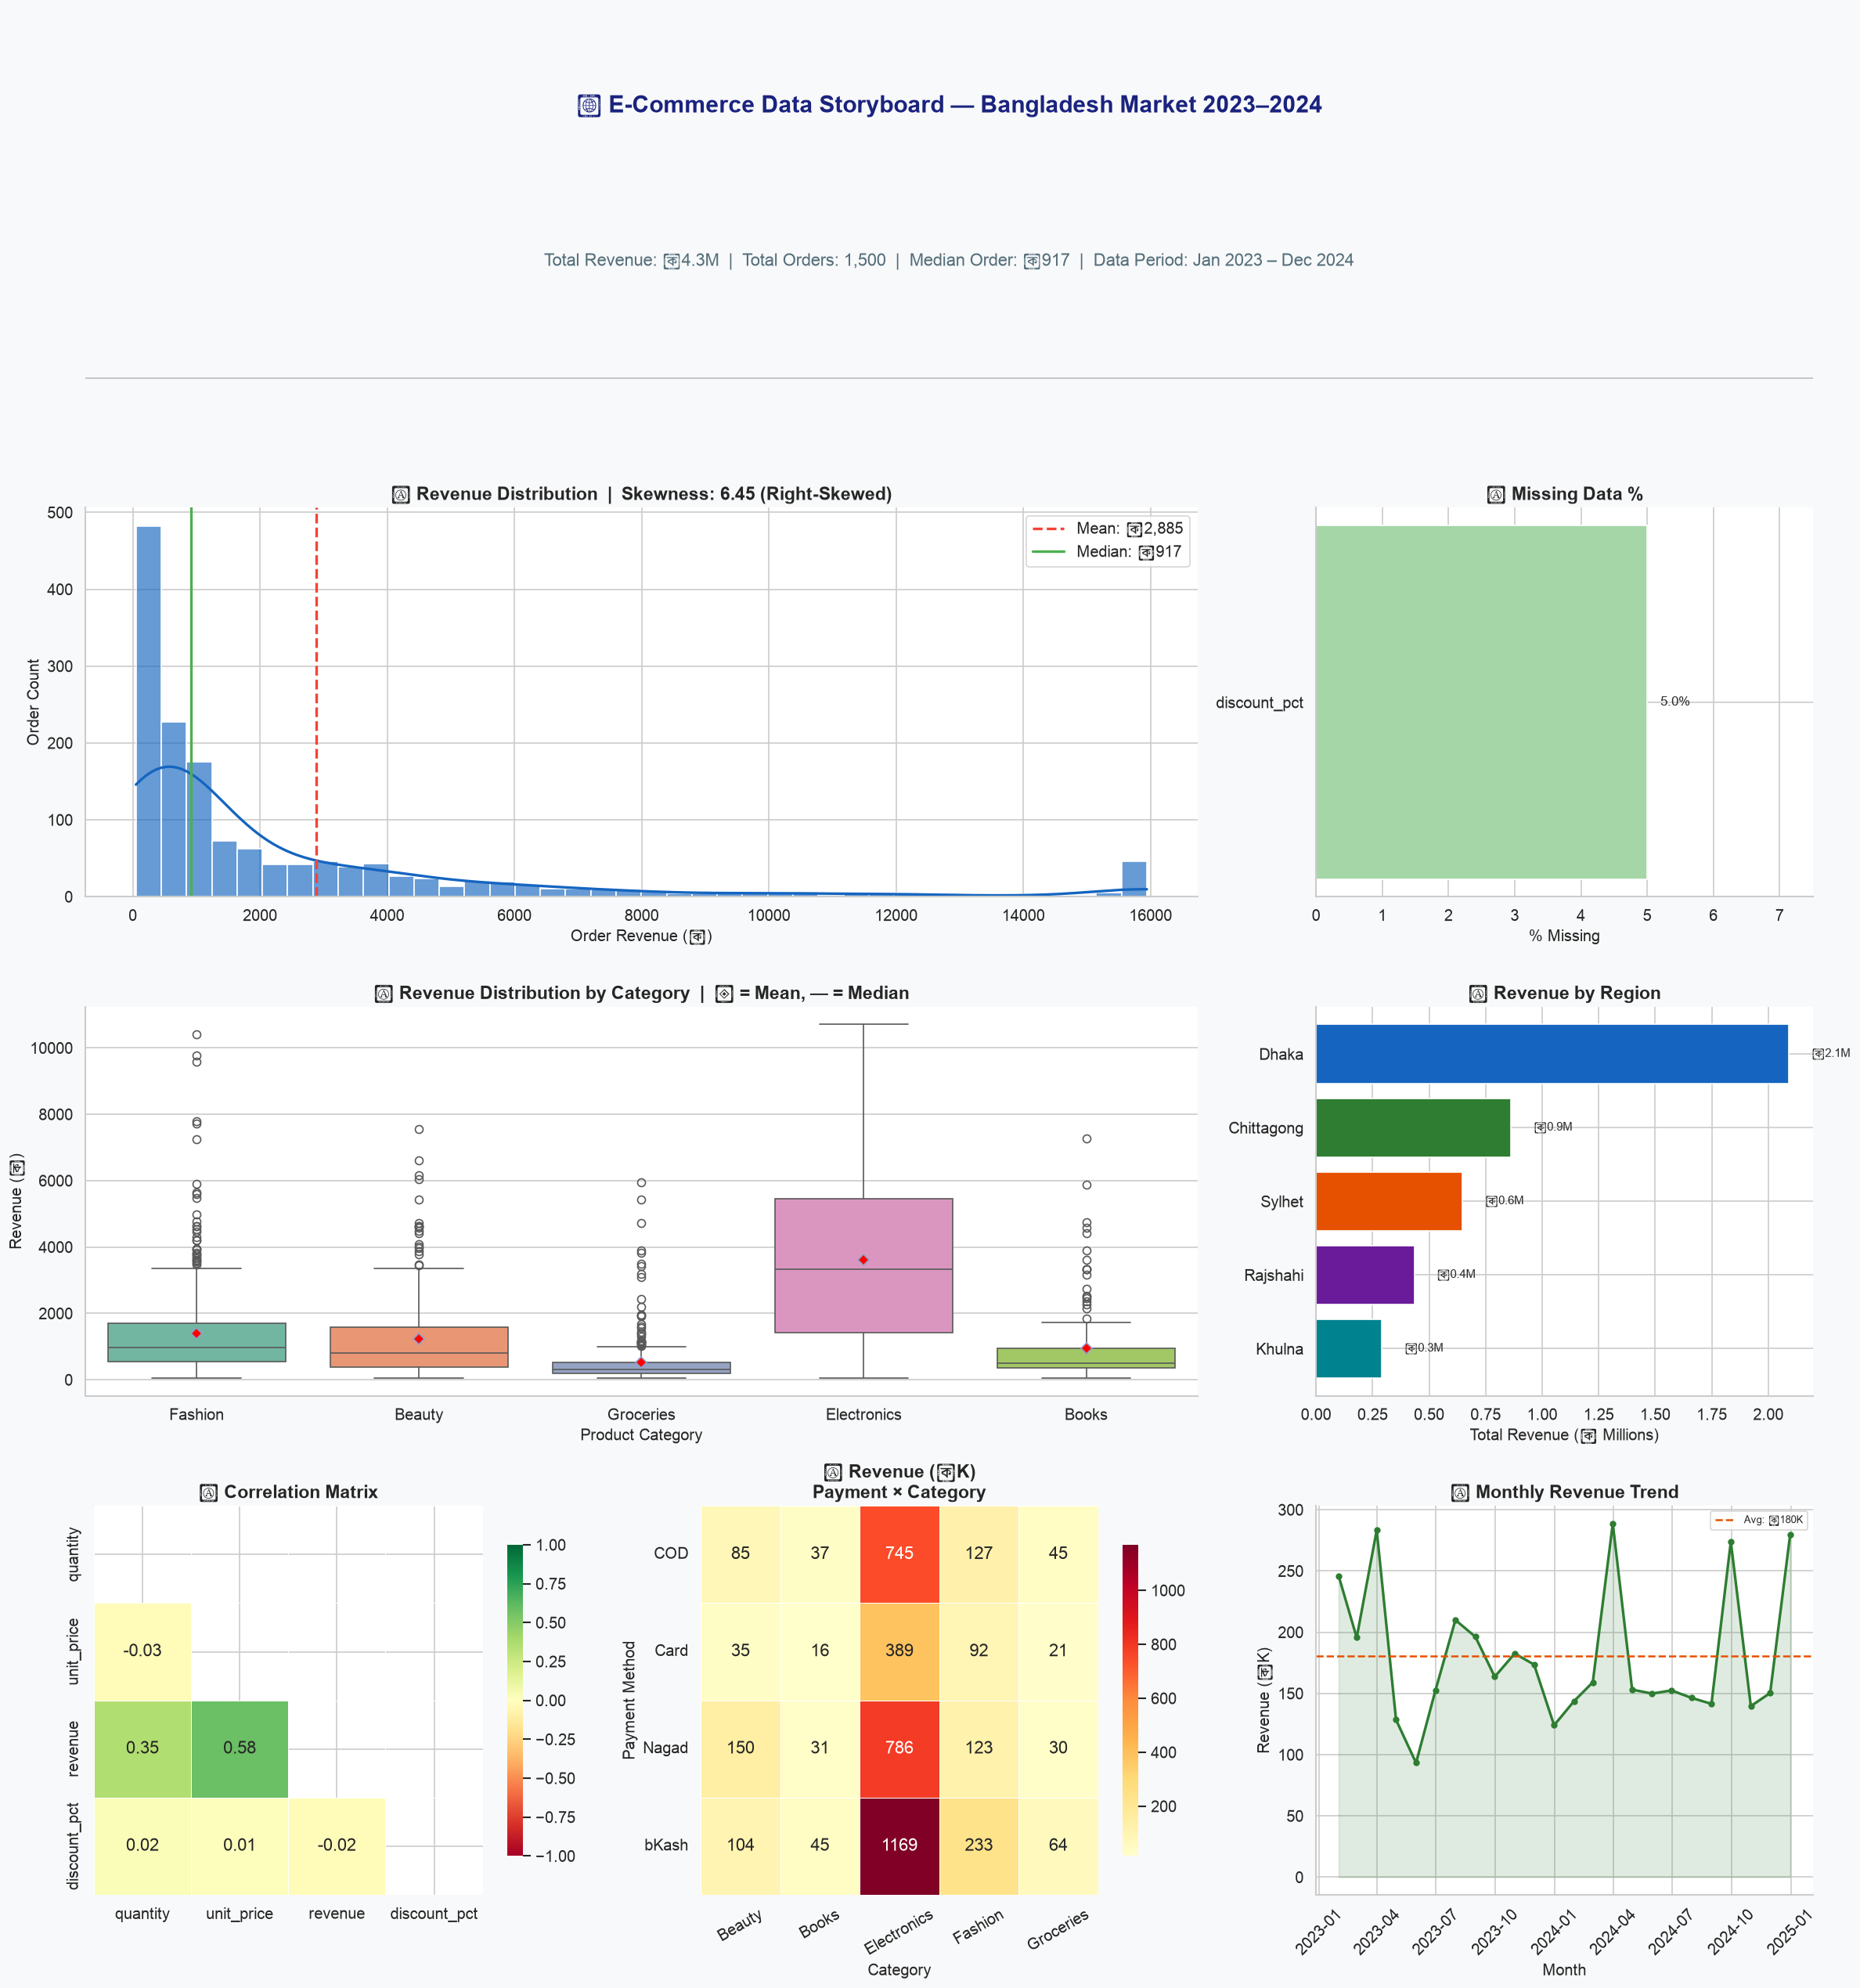


✅ Data Storyboard saved as 'data_storyboard.png'


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 7.1 — DATA STORYBOARD: Complete 7-Panel EDA Report
# ─────────────────────────────────────────────────────────────
# This is the capstone cell. It produces one professional figure
# with 7 coordinated panels — suitable for a business presentation.
#
# STRUCTURE: We use plt.subplot2grid() for flexible panel sizing.
# WHY subplot2grid over subplots():
#   subplot2grid lets panels span different numbers of columns/rows.
#   E.g., the title panel spans all 3 columns. The trend line spans
#   2 columns. This creates visual hierarchy — more important panels get more space.

# ── Color Palette ────────────────────────────────────────────
COLORS = {
    'primary':   '#1565C0',   # Deep blue — main emphasis
    'secondary': '#2E7D32',   # Deep green — positive trend
    'accent':    '#E65100',   # Deep orange — warnings/outliers
    'neutral':   '#546E7A',   # Blue-gray — secondary elements
    'palette':   ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#00838F'],
}

# ── Figure Setup: 3 rows × 3 columns grid ────────────────────
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#F8F9FA')   # WHY: Light gray background looks more professional

# ── PANEL 0: Title Header ────────────────────────────────────
ax0 = plt.subplot2grid((4, 3), (0, 0), colspan=3)  # Row 0, spans all 3 columns
ax0.axis('off')  # WHY: Title panel has no chart — just text

total_revenue = df['revenue'].sum()
total_orders  = len(df)
avg_order     = df['revenue'].median()  # Median, not mean, for typical order

# KPIs in the title bar
ax0.text(0.5, 0.75, '📊 E-Commerce Data Storyboard — Bangladesh Market 2023–2024',
         transform=ax0.transAxes, fontsize=18, fontweight='bold',
         ha='center', va='center', color='#1A237E')
ax0.text(0.5, 0.35,
         f'Total Revenue: ৳{total_revenue/1_000_000:.1f}M  |  '
         f'Total Orders: {total_orders:,}  |  '
         f'Median Order: ৳{avg_order:,.0f}  |  '
         f'Data Period: Jan 2023 – Dec 2024',
         transform=ax0.transAxes, fontsize=13, ha='center', va='center',
         color=COLORS['neutral'])
ax0.axhline(0.05, color='#BDBDBD', linewidth=1)  # Divider line

# ── PANEL 1: Revenue Distribution (Histogram + KDE) ──────────
ax1 = plt.subplot2grid((4, 3), (1, 0), colspan=2)  # Row 1, spans 2 columns
revenue_clipped = df['revenue'].clip(upper=df['revenue'].quantile(0.97))
sns.histplot(revenue_clipped, bins=40, kde=True, color=COLORS['primary'],
             alpha=0.65, ax=ax1, line_kws={'linewidth': 2})
ax1.axvline(df['revenue'].mean(),   color='#F44336', linewidth=2, linestyle='--',
            label=f"Mean: ৳{df['revenue'].mean():,.0f}")
ax1.axvline(df['revenue'].median(), color='#4CAF50', linewidth=2, linestyle='-',
            label=f"Median: ৳{df['revenue'].median():,.0f}")
ax1.set_title(f"① Revenue Distribution  |  Skewness: {df['revenue'].skew():.2f} (Right-Skewed)",
              fontweight='bold')
ax1.set_xlabel('Order Revenue (৳)')
ax1.set_ylabel('Order Count')
ax1.legend()

# ── PANEL 2: Missing Value Summary (Bar) ─────────────────────
ax2 = plt.subplot2grid((4, 3), (1, 2))  # Row 1, Column 2
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]  # Only show columns with missing values
colors_missing = ['#EF9A9A' if v > 10 else '#FFF176' if v > 5 else '#A5D6A7'
                  for v in missing_pct.values]
ax2.barh(missing_pct.index, missing_pct.values, color=colors_missing, edgecolor='white')
for i, (col, pct) in enumerate(missing_pct.items()):
    ax2.text(pct + 0.2, i, f'{pct:.1f}%', va='center', fontsize=10)
ax2.set_title('② Missing Data %', fontweight='bold')
ax2.set_xlabel('% Missing')
ax2.set_xlim(0, max(missing_pct.values) * 1.3 + 1)

# ── PANEL 3: Category Revenue Comparison (Boxplot) ───────────
ax3 = plt.subplot2grid((4, 3), (2, 0), colspan=2)  # Row 2, spans 2 columns
df_p3 = df[df['revenue'] < df['revenue'].quantile(0.95)].copy()
sns.boxplot(data=df_p3, x='category', y='revenue', palette='Set2',
            showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 6},
            ax=ax3)
ax3.set_title('③ Revenue Distribution by Category  |  ◆ = Mean, — = Median',
              fontweight='bold')
ax3.set_xlabel('Product Category')
ax3.set_ylabel('Revenue (৳)')

# ── PANEL 4: Regional Order Volume (Horizontal Bar) ──────────
ax4 = plt.subplot2grid((4, 3), (2, 2))  # Row 2, Column 2
region_rev = df.groupby('customer_region')['revenue'].sum().sort_values() / 1_000_000
bars = ax4.barh(region_rev.index, region_rev.values,
                color=COLORS['palette'][::-1], edgecolor='white')
for bar, val in zip(bars, region_rev.values):
    ax4.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'৳{val:.1f}M', va='center', fontsize=9)
ax4.set_title('④ Revenue by Region', fontweight='bold')
ax4.set_xlabel('Total Revenue (৳ Millions)')

# ── PANEL 5: Correlation Heatmap ─────────────────────────────
ax5 = plt.subplot2grid((4, 3), (3, 0))  # Row 3, Column 0
num_df = df[['quantity', 'unit_price', 'revenue', 'discount_pct']].dropna()
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, ax=ax5)
ax5.set_title('⑤ Correlation Matrix', fontweight='bold')

# ── PANEL 6: Payment Method + Category Heatmap ───────────────
ax6 = plt.subplot2grid((4, 3), (3, 1))  # Row 3, Column 1
pivot = df.groupby(['payment_method', 'category'])['revenue'].sum().unstack().fillna(0) / 1000
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, ax=ax6,
            cbar_kws={'shrink': 0.8})
ax6.set_title('⑥ Revenue (৳K)\nPayment × Category', fontweight='bold')
ax6.set_xlabel('Category')
ax6.set_ylabel('Payment Method')
ax6.tick_params(axis='x', rotation=30)
ax6.tick_params(axis='y', rotation=0)

# ── PANEL 7: Monthly Revenue Trend ───────────────────────────
ax7 = plt.subplot2grid((4, 3), (3, 2))  # Row 3, Column 2
monthly_rev = df.set_index('order_date')['revenue'].resample('ME').sum() / 1_000
ax7.plot(monthly_rev.index, monthly_rev.values, color=COLORS['secondary'],
         linewidth=2, marker='o', markersize=4)
ax7.fill_between(monthly_rev.index, monthly_rev.values,
                 alpha=0.15, color=COLORS['secondary'])  # WHY fill_between: Shows volume visually
ax7.axhline(monthly_rev.mean(), color=COLORS['accent'],
            linestyle='--', linewidth=1.5,
            label=f"Avg: ৳{monthly_rev.mean():.0f}K")
ax7.set_title('⑦ Monthly Revenue Trend', fontweight='bold')
ax7.set_xlabel('Month')
ax7.set_ylabel('Revenue (৳K)')
ax7.tick_params(axis='x', rotation=45)
ax7.legend(fontsize=8)

plt.suptitle('', y=0)  # Suppress extra space
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('data_storyboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("\n✅ Data Storyboard saved as 'data_storyboard.png'")

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 7.2 — Generate Written Insights from the Storyboard
# ─────────────────────────────────────────────────────────────
# WHAT: Automated narrative summary of the 7 panels.
# MOTIVE: A storyboard without written insights is incomplete.
# Data science is communication. The chart shows what. You explain why it matters.

print("" * 60)
print("═" * 60)
print("   📊 DATA STORYBOARD — EXECUTIVE INSIGHTS SUMMARY")
print("═" * 60)

total_rev     = df['revenue'].sum()
total_orders  = len(df)
top_cat       = df.groupby('category')['revenue'].sum().idxmax()
top_region    = df.groupby('customer_region')['revenue'].sum().idxmax()
top_payment   = df['payment_method'].value_counts().index[0]
skew_val      = df['revenue'].skew()
mean_rev      = df['revenue'].mean()
median_rev    = df['revenue'].median()
n_outliers    = (df['revenue'] > df['revenue'].quantile(0.99)).sum()

print(f"""
① REVENUE HEALTH
   Total Revenue : ৳{total_rev/1_000_000:.2f}M across {total_orders:,} orders
   Mean Order    : ৳{mean_rev:,.0f}  |  Median Order: ৳{median_rev:,.0f}
   Revenue is right-skewed (skewness={skew_val:.2f}) — a few large orders
   inflate the mean. Use MEDIAN as the representative order value.

② MISSING DATA
   discount_pct has {df['discount_pct'].isna().sum()} missing values ({df['discount_pct'].isna().mean()*100:.1f}%).
   Impute with median ({df['discount_pct'].median():.1f}%) before modeling.

③ CATEGORY PERFORMANCE
   Top revenue driver: {top_cat}
   Electronics has the widest IQR — most variable revenue per order.
   Groceries is the most stable (predictable, low-margin segment).

④ REGIONAL DEMAND
   {top_region} dominates with {df[df['customer_region']==top_region]['revenue'].sum()/total_rev*100:.0f}% of total revenue.
   Opportunity: Chittagong and Sylhet are under-penetrated markets.

⑤ CORRELATIONS
   Revenue is strongly correlated with unit_price (expected — higher priced
   items generate more revenue per order).
   discount_pct shows low correlation with revenue — discounts alone don't
   predict high-value orders.

⑥ PAYMENT BEHAVIOR
   {top_payment} is the most used payment method.
   Electronics buyers prefer Card/bKash (large amounts).
   Grocery buyers prefer COD (low trust for online payment on small orders).

⑦ TREND ANALYSIS
   Monthly revenue fluctuates around ৳{monthly_rev.mean():,.0f}K average.
   Peak months: Q4 (festival season — Eid, year-end sales).
   Recommendation: Pre-stock Electronics and Fashion inventory for Q4.
""")
print("═" * 60)


════════════════════════════════════════════════════════════
   📊 DATA STORYBOARD — EXECUTIVE INSIGHTS SUMMARY
════════════════════════════════════════════════════════════

① REVENUE HEALTH
   Total Revenue : ৳4.33M across 1,500 orders
   Mean Order    : ৳2,885  |  Median Order: ৳917
   Revenue is right-skewed (skewness=6.45) — a few large orders
   inflate the mean. Use MEDIAN as the representative order value.

② MISSING DATA
   discount_pct has 75 missing values (5.0%).
   Impute with median (25.5%) before modeling.

③ CATEGORY PERFORMANCE
   Top revenue driver: Electronics
   Electronics has the widest IQR — most variable revenue per order.
   Groceries is the most stable (predictable, low-margin segment).

④ REGIONAL DEMAND
   Dhaka dominates with 48% of total revenue.
   Opportunity: Chittagong and Sylhet are under-penetrated markets.

⑤ CORRELATIONS
   Revenue is strongly correlated with unit_price (expected — higher priced
   items generate more revenue per order).
   discount

---
## 🎯 Class Exercise — Build Your Own Storyboard

Using what you've learned, complete the following exercises:

### Exercise 1 — Replace the Dataset
Load any real CSV of your choice (Kaggle, or your own). Replace `df` in Section 1
and re-run all cells. How do the distributions change?

### Exercise 2 — Add an 8th Panel
Add a panel to the Storyboard showing **discount_pct distribution by category**.
Do premium categories (Electronics) get fewer discounts?

### Exercise 3 — Log Transform
The revenue distribution is right-skewed. Apply `np.log1p()` transform and
re-plot the histogram. What happens to the skewness?
```python
df['revenue_log'] = np.log1p(df['revenue'])
```

### Exercise 4 — Z-Score Outlier Detection
Write a function that:
1. Computes z-scores for a given column
2. Flags rows where `|z| > 3` as outliers
3. Returns a DataFrame with the flagged rows

### Exercise 5 — Business Report
Write a 5-bullet executive summary of the dataset insights from your storyboard.
Each bullet must reference a specific statistic from your analysis.

---
*End of Class 5 Notebook — Visual EDA & Descriptive Statistics*

*Next Class → Feature Engineering: Transformations, Encoding, and Scaling*